In [1]:
!pip install -q rasterio

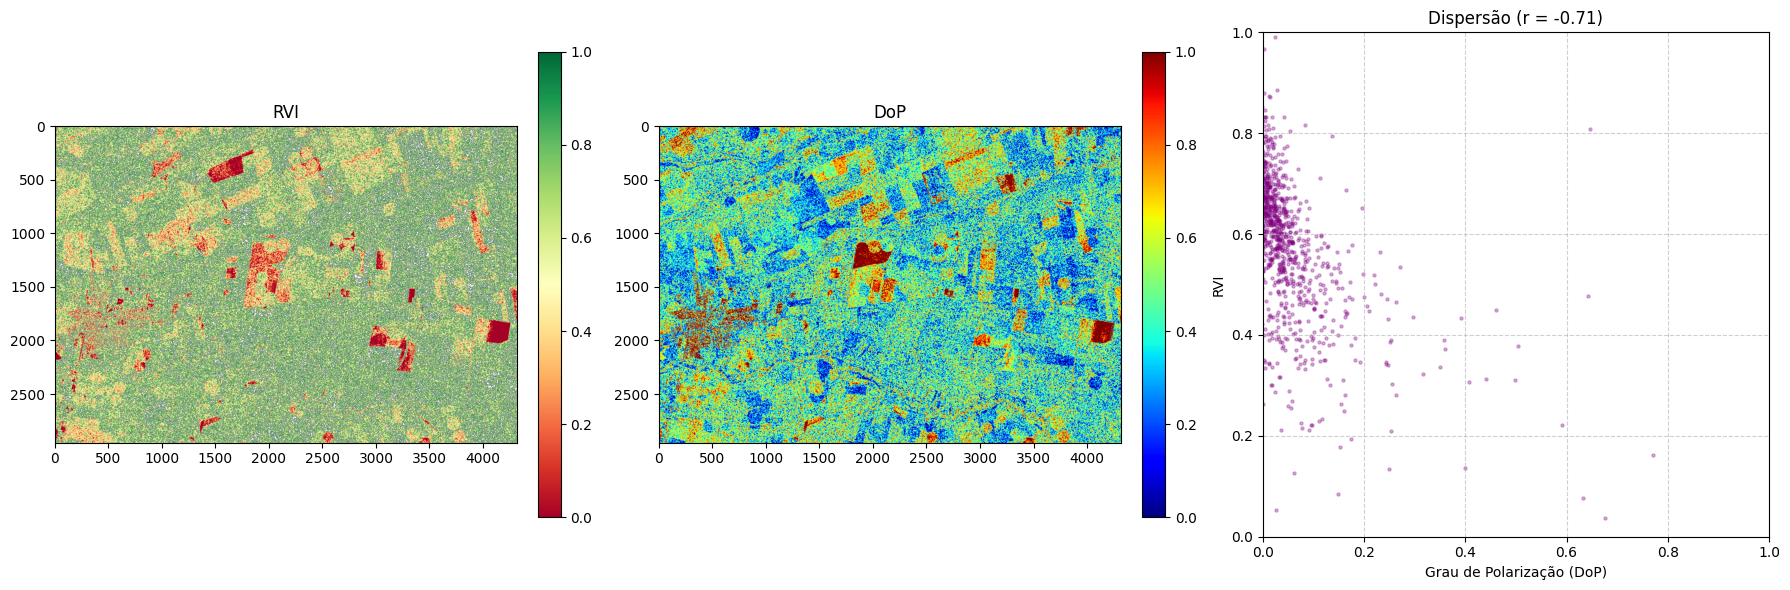

In [12]:
# Importação de bibliotecas
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# 1. Leitura dos arquivos raster (em dB)
with rio.open('S1A_VH.tif') as src:
    VH_db = src.read(1).astype(float)
with rio.open('S1A_VV.tif') as src:
    VV_db = src.read(1).astype(float)

# 2. Conversão de Decibel (dB) para Escala Linear (Power)
VH = 10 ** (VH_db / 10.0)
VV = 10 ** (VV_db / 10.0)

# Tratamento para evitar divisão por zero
denominador = VV + VH
denominador[denominador == 0] = np.nan

# 3. Cálculo dos Índices na escala
RVI = (4 * VH) / denominador
DoP = VV - VH / denominador

# 4. Remoção  de Outliers
DoP = np.where((DoP >= -1) & (DoP <= 1), DoP, np.nan)
RVI = np.where((RVI >= -1) & (RVI <= 1), RVI, np.nan)

# 5. Função de expansão (contraste) ignorando NaNs
def expansao(img, percent_ini=2, percent_fim=98):
    s = np.zeros_like(img)
    x, y = 0, 1
    valid_mask = ~np.isnan(img)

    if not np.any(valid_mask):
        return img

    w = np.percentile(img[valid_mask], percent_ini)
    z = np.percentile(img[valid_mask], percent_fim)

    if z == w:
        return s

    p = x + (img - w) * (y - x) / (z - w)
    p[p < x] = x
    p[p > y] = y
    s = p
    s[~valid_mask] = np.nan
    return s

# 6. Cálculo da Correlação Estatística sem Outliers
flat_rvi = RVI.flatten()
flat_dop = DoP.flatten()
mask = ~np.isnan(flat_rvi) & ~np.isnan(flat_dop)

if np.any(mask):
    corr, _ = pearsonr(flat_dop[mask], flat_rvi[mask])


# 7. Visualização Comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Mapa RVI limpo
im1 = axes[0].imshow(expansao(RVI), cmap='RdYlGn')
axes[0].set_title('RVI')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Mapa DoP limpo
im2 = axes[1].imshow(expansao(DoP), cmap='jet')
axes[1].set_title('DoP')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# Gráfico de Dispersão (Scatter Plot)
if np.any(mask):
    sample_size = min(5000, np.sum(mask))
    sample_idx = np.random.choice(np.where(mask)[0], size=sample_size, replace=False)
    axes[2].scatter(flat_dop[sample_idx], flat_rvi[sample_idx], alpha=0.3, s=5, c='purple')
    axes[2].set_title(f'Dispersão (r = {corr:.2f})')
    axes[2].set_xlabel('Grau de Polarização (DoP)')
    axes[2].set_ylabel('RVI')
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1)
    axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()